# Market Risk VaR

Market Risk Value at Risk (VaR) is a statistical metric used to estimate the maximum expected loss on an investment portfolio over a specific time horizon, under normal market conditions, and at a given confidence level.

### Every VaR figure relies on three critical variables:

**Time Horizon:** The period over which potential losses are measured (e.g., 1 day, 1 week, or 1 month).

**Confidence Level:** The statistical probability that losses will not exceed the VaR estimate (usually 95% or 99%).

**Loss Amount:** The worst-case loss expressed as an exact currency figure or a portfolio percentage.

### Importing librabries and defining project theme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", "{:.6f}".format)

# DEFINE

## Business Problem

Market risk is the exposure to losses arising from adverse movements in market prices equities, interest rates, FX rates, and commodity prices. For financial institutions and asset managers, quantifying this risk is not optional.

## Problem statement

The risk team lacks a unified, methodology-agnostic framework to estimate daily portfolio loss potential. Relying on a single VaR method produces blind spots especially during tail events like market crises, where standard assumptions break down.

**Confidence levels:** 95% and 99%  
**Time horizon:** 1-day and 10-day VaR  
**CTQ (Critical to Quality):** Accurate daily P&L loss boundary at 99% confidence, stable under backtesting.


# Measure

### Dataset variables

**Date:** Business day timestamp. Defines the time horizon for return calculation and rolling windows.

**Asset_ID:** Unique identifier for each instrument (e.g. AAPL, EUR=X, GLD). String key for joins and grouping.

**Asset_Class:** Instrument category: Equity, FX, Commodity, or Fixed Income. Used to segment and aggregate risk by class.

**Sector:** Industry or sub-class (Technology, Energy, Gold, Bonds, etc.). Enables sector-level VaR decomposition.

**Currency:** Base currency of the instrument (USD, EUR, GBP). Required for FX exposure and conversion risk.

**Price:** Raw closing market price in local currency. Base series from which returns and P&L are derived.

**Return:** Daily log return (price_t / price_t-1 - 1). Core input for all three VaR distribution models.

**Volatility:** 20-day rolling standard deviation of returns. Primary input for parametric (variance-covariance) VaR.

**Position_Size:** Number of units held in the portfolio. Scales individual asset risk to dollar exposure.



### Dataset uploaded

In [2]:
df = pd.read_csv("market_risk_var.csv", parse_dates=["Date"])
df

,Date,Asset_ID,Asset_Class,Sector,Currency,Price,Return,Volatility,Position_Size
0,2020-01-01,AAPL,Equity,Technology,USD,150.000000,0.000119,NaN,388.090000
1,2020-01-02,AAPL,Equity,Technology,USD,150.217600,0.001451,0.000942,388.090000
2,2020-01-03,AAPL,Equity,Technology,USD,150.095600,-0.000812,0.001138,388.090000
3,2020-01-06,AAPL,Equity,Technology,USD,150.183300,0.000584,0.000943,388.090000
4,2020-01-07,AAPL,Equity,Technology,USD,150.279000,0.000637,0.000828,388.090000
...,...,...,...,...,...,...,...,...,...
12511,2023-12-25,BTC-X,Commodity,Crypto,USD,24822.195700,0.003095,0.003517,3.310000
12512,2023-12-26,BTC-X,Commodity,Crypto,USD,24731.487100,-0.003654,0.003561,3.310000
12513,2023-12-27,BTC-X,Commodity,Crypto,USD,24785.719800,0.002193,0.003490,3.310000
12514,2023-12-28,BTC-X,Commodity,Crypto,USD,24856.838500,0.002869,0.003538,3.310000


# ANALYZE

### Getting basic information from dataset

In [3]:
print("=== dtypes ===")
print(df.dtypes)
print("\n=== Missing values ===")
print(df.isnull().sum())
print("\n=== Basic Stats ===")
df.describe()

=== dtypes ===
Date             datetime64[ns]
Asset_ID                 object
Asset_Class              object
Sector                   object
Currency                 object
Price                   float64
Return                  float64
Volatility              float64
Position_Size           float64
dtype: object

=== Missing values ===
Date              0
Asset_ID          0
Asset_Class       0
Sector            0
Currency          0
Price             0
Return            0
Volatility       12
Position_Size     0
dtype: int64

=== Basic Stats ===


,Price,Return,Volatility,Position_Size
count,12516.000000,12516.000000,12504.000000,12516.000000
mean,2637.492328,-0.000025,0.001578,12340.866667
std,7495.564830,0.001878,0.001009,26283.168379
min,1.089300,-0.015090,0.000095,3.310000
25%,71.223575,-0.000819,0.000652,348.485000
50%,133.799950,0.000000,0.001537,906.095000
75%,196.687875,0.000784,0.002134,1586.435000
max,31518.111000,0.011892,0.006167,81059.100000


### Portfolio Features and Statistics

In [4]:
# Pivot to wide format: one column per asset
returns_wide = df.pivot_table(index="Date", columns="Asset_ID", values="Return")
prices_wide  = df.pivot_table(index="Date", columns="Asset_ID", values="Price")

# Position sizes (constant per asset)
position_map = df.groupby("Asset_ID")["Position_Size"].first()

# Dollar P&L per asset per day
pnl_wide = returns_wide.multiply(
    prices_wide.shift(1), axis=0
).multiply(position_map, axis=1)

# Portfolio-level daily P&L
portfolio_pnl = pnl_wide.sum(axis=1).dropna()

print(f"Assets          : {returns_wide.shape[1]}")
print(f"Trading days    : {returns_wide.shape[0]}")
print(f"Portfolio P&L mean  : ${portfolio_pnl.mean():,.0f}")
print(f"Portfolio P&L std   : ${portfolio_pnl.std():,.0f}")
print(f"Worst single day    : ${portfolio_pnl.min():,.0f}")
print(f"Best single day     : ${portfolio_pnl.max():,.0f}")

Assets          : 12
Trading days    : 1043
Portfolio P&L mean  : $-30
Portfolio P&L std   : $878
Worst single day    : $-4,719
Best single day     : $4,106


### Portfolio Daily P&L Over Time

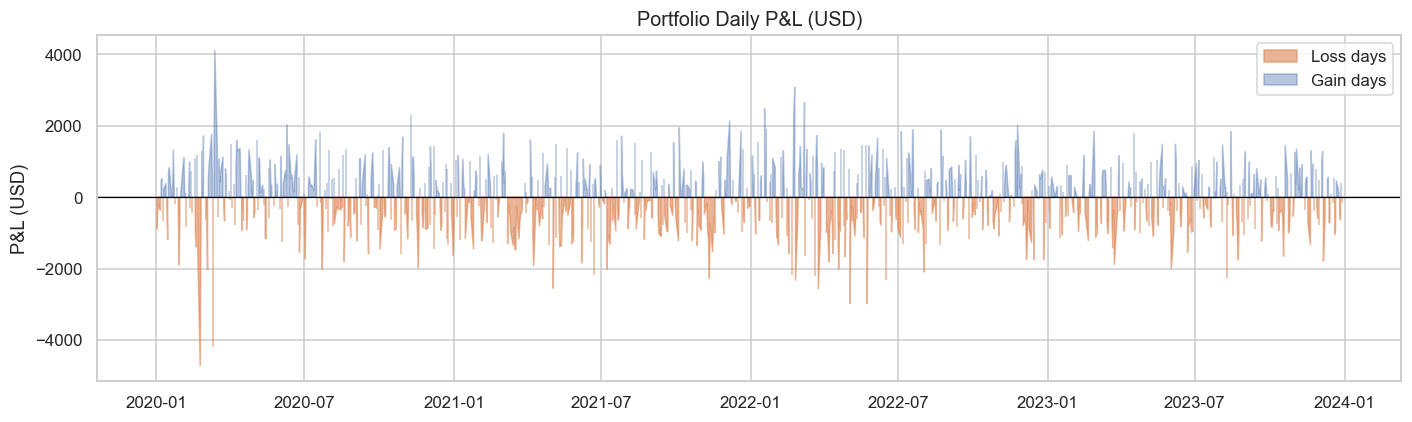

In [5]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(portfolio_pnl.index, portfolio_pnl, 0,
                where=(portfolio_pnl < 0), color="#DD8452", alpha=0.6, label="Loss days")
ax.fill_between(portfolio_pnl.index, portfolio_pnl, 0,
                where=(portfolio_pnl >= 0), color="#4C72B0", alpha=0.4, label="Gain days")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Portfolio Daily P&L (USD)", fontsize=13)
ax.set_ylabel("P&L (USD)")
ax.legend()
plt.tight_layout()
plt.show()


### Return Distributions by Asset Class

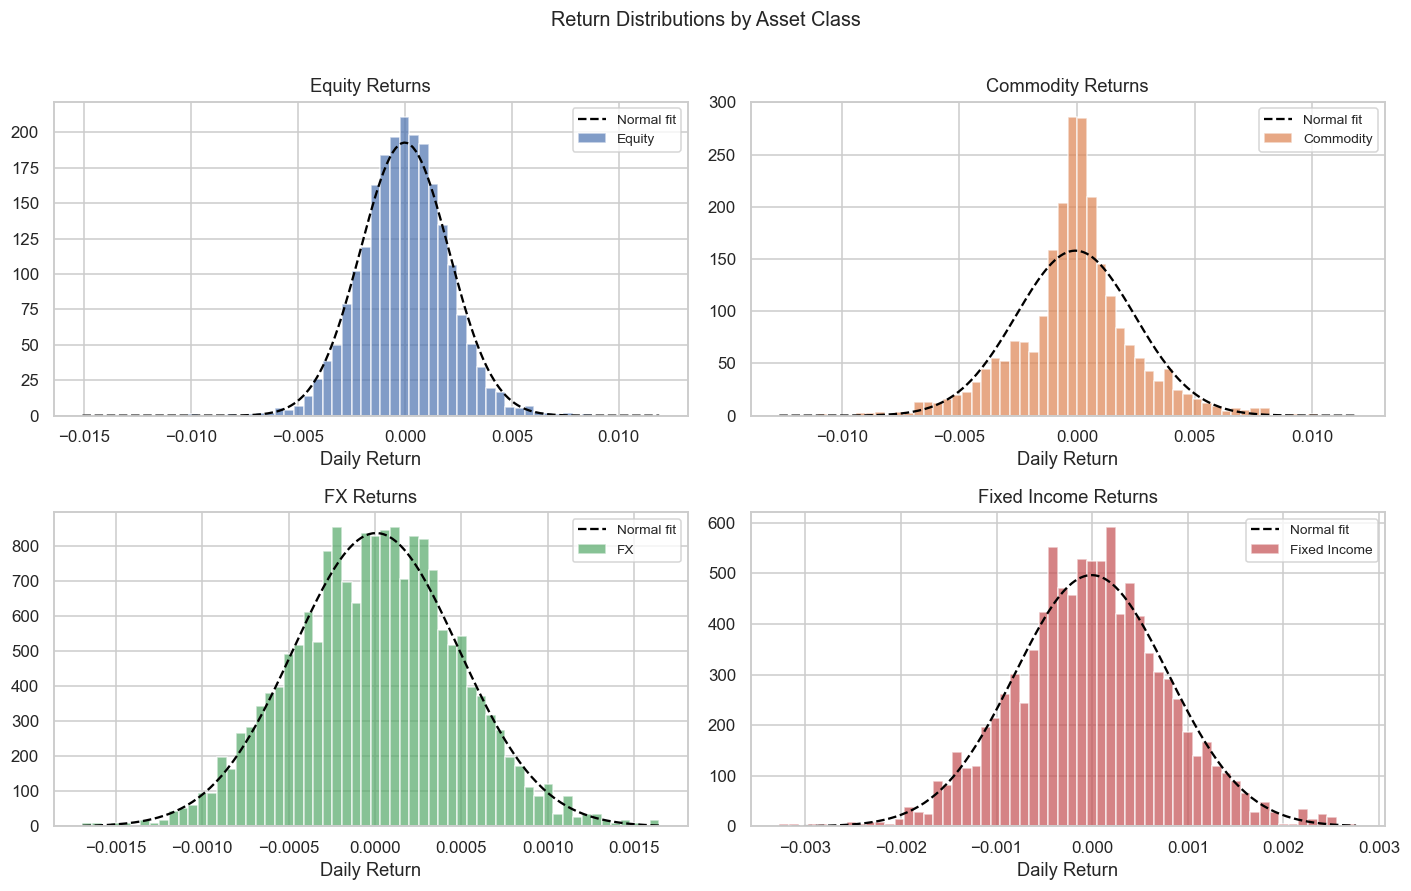

In [6]:
asset_classes = df.groupby("Asset_ID")["Asset_Class"].first()
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
classes = ["Equity", "Commodity", "FX", "Fixed Income"]
colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for ax, cls, col in zip(axes.flatten(), classes, colors):
    assets = asset_classes[asset_classes == cls].index.tolist()
    data = returns_wide[assets].stack().dropna()
    ax.hist(data, bins=60, color=col, alpha=0.7, density=True, label=cls)
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, norm.pdf(x, mu, sigma), color="black", lw=1.5, linestyle="--", label="Normal fit")
    ax.set_title(f"{cls} Returns")
    ax.set_xlabel("Daily Return")
    ax.legend(fontsize=9)

plt.suptitle("Return Distributions by Asset Class", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Correlation Matrix

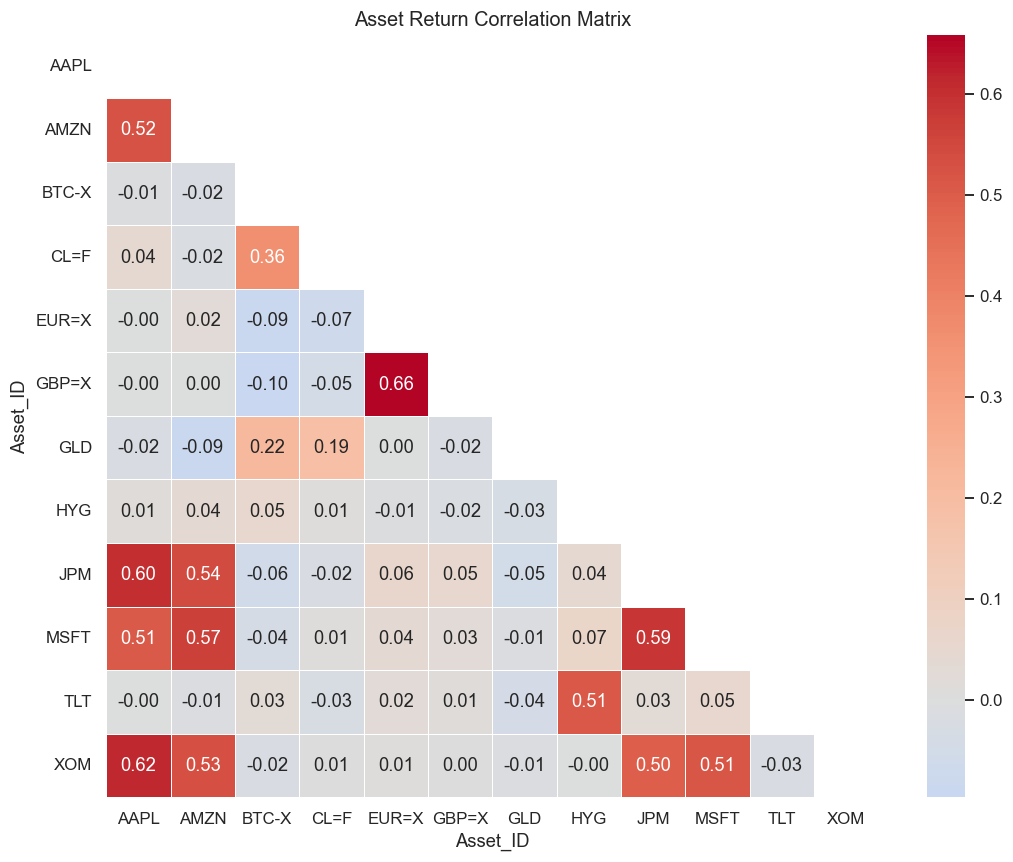

In [7]:
corr = returns_wide.corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.4, ax=ax)
ax.set_title("Asset Return Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.show()


### Rolling Volatility by Asset

The resulting line chart lets a quant visually compare which stocks are consistently riskier (higher volatility) and see how market turbulence spikes or subsides for each asset over the time period.

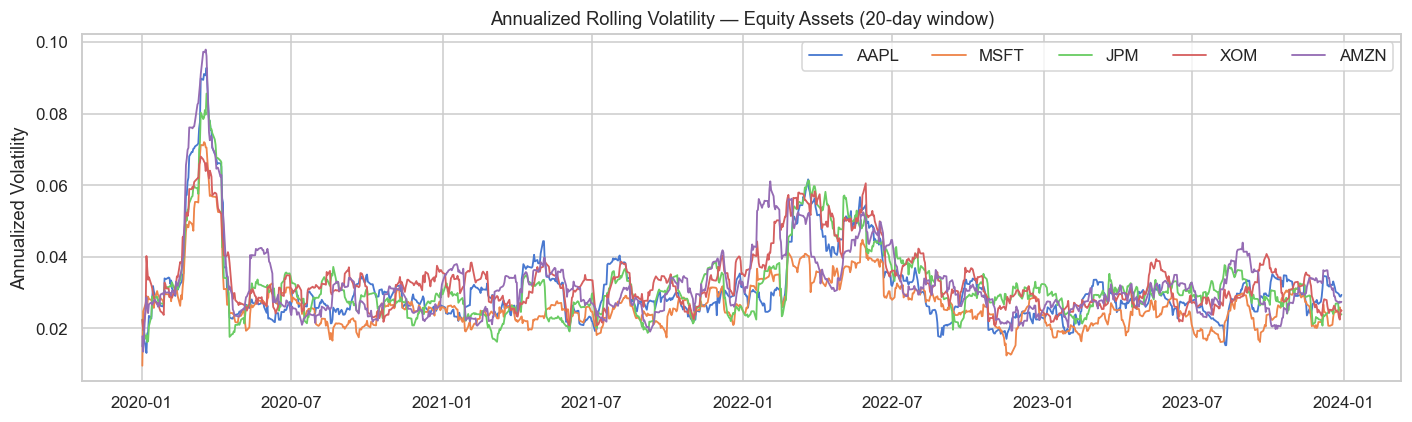

In [8]:
vol_wide = df.pivot_table(index="Date", columns="Asset_ID", values="Volatility")
equity_assets = ["AAPL", "MSFT", "JPM", "XOM", "AMZN"]

fig, ax = plt.subplots(figsize=(13, 4))
for asset in equity_assets:
    ax.plot(vol_wide.index, vol_wide[asset] * np.sqrt(252),
            label=asset, linewidth=1.2)
ax.set_title("Annualized Rolling Volatility — Equity Assets (20-day window)")
ax.set_ylabel("Annualized Volatility")
ax.legend(ncol=5)
plt.tight_layout()
plt.show()

### VaR Method 1 — Historical Simulation


Calculating Historical Simulation VaR by taking the actual historical daily portfolio profits/losses and finding the loss threshold at the 95th and 99th percentiles.

The red shaded tail area visually highlights the "worst 1% of days" that VaR ignores, showing exactly why quants pair VaR with Expected Shortfall to capture the true severity of market crashes.

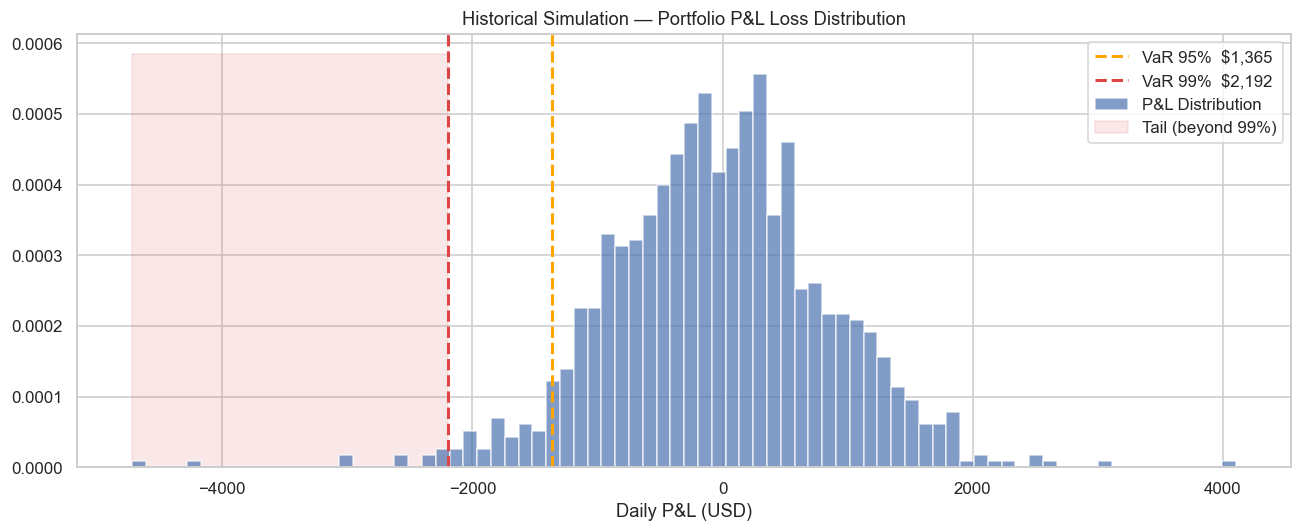

Historical VaR 95% : $       1,365
Historical VaR 99% : $       2,192
Expected Shortfall  : $       2,851  (average loss beyond VaR 99%)


In [9]:
CONFIDENCE_LEVELS = [0.95, 0.99]

def historical_var(pnl_series, confidence=0.99):
    return -np.percentile(pnl_series, (1 - confidence) * 100)

hs_var_95 = historical_var(portfolio_pnl, 0.95)
hs_var_99 = historical_var(portfolio_pnl, 0.99)
hs_es_99  = -portfolio_pnl[portfolio_pnl <= -hs_var_99].mean()  # Expected Shortfall

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(portfolio_pnl, bins=80, color="#4C72B0", alpha=0.7, density=True, label="P&L Distribution")
ax.axvline(-hs_var_95, color="#FFA500", linewidth=2, linestyle="--", label=f"VaR 95%  ${hs_var_95:,.0f}")
ax.axvline(-hs_var_99, color="#DD4444", linewidth=2, linestyle="--", label=f"VaR 99%  ${hs_var_99:,.0f}")
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 0.0003],
                 portfolio_pnl.min(), -hs_var_99,
                 color="#DD4444", alpha=0.12, label="Tail (beyond 99%)")
ax.set_title("Historical Simulation — Portfolio P&L Loss Distribution")
ax.set_xlabel("Daily P&L (USD)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Historical VaR 95% : ${hs_var_95:>12,.0f}")
print(f"Historical VaR 99% : ${hs_var_99:>12,.0f}")
print(f"Expected Shortfall  : ${hs_es_99:>12,.0f}  (average loss beyond VaR 99%)")

### VaR Method 2 — Variance-Covariance (Parametric)

It calculates Parametric (Variance-Covariance) VaR by assuming portfolio returns follow a normal distribution, then using the portfolio's average daily return and standard deviation to compute the loss thresholds at the 5th and 1st percentiles (95% and 99% confidence).

It overlays a fitted normal curve on top of the actual histogram of historical P&L, visually showing how well or poorly the normal distribution matches reality.

The Shapiro-Wilk test at the end quantitatively checks whether the returns are actually normal—if the p-value is below 0.05, the model is statistically invalid, highlighting the fatal flaw of assuming markets follow a bell curve.

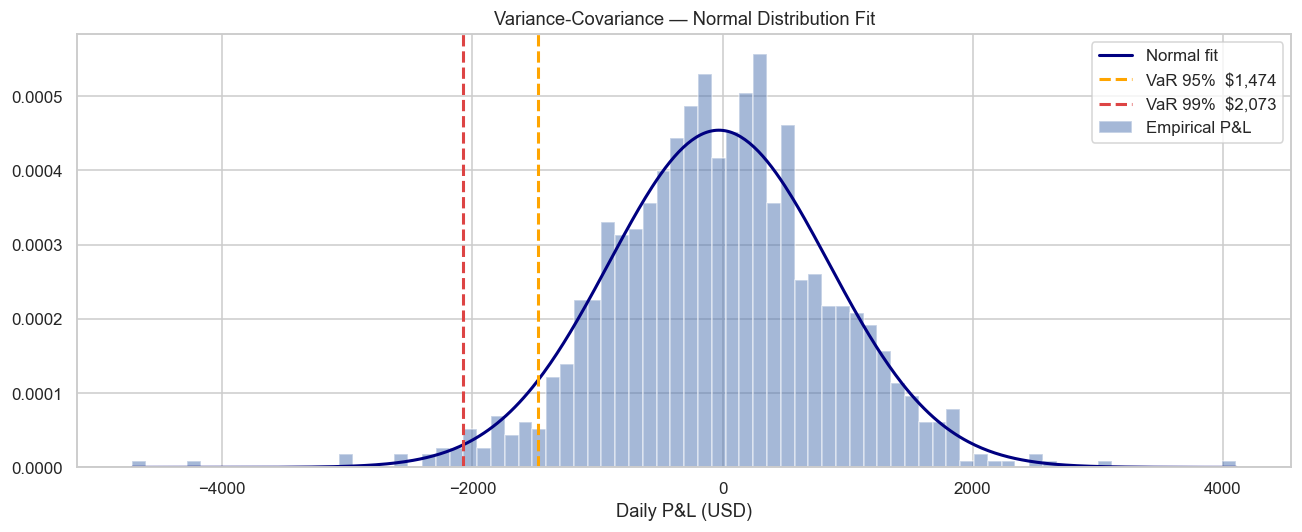

Parametric VaR 95% : $       1,474
Parametric VaR 99% : $       2,073

Shapiro-Wilk normality test on P&L sample:
  W=0.9969  p=4.5629e-01  →  Cannot reject normality


In [10]:
mu_p    = portfolio_pnl.mean()
sigma_p = portfolio_pnl.std()

vc_var_95 = -(mu_p + norm.ppf(0.05) * sigma_p)
vc_var_99 = -(mu_p + norm.ppf(0.01) * sigma_p)

x = np.linspace(portfolio_pnl.min(), portfolio_pnl.max(), 500)
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(portfolio_pnl, bins=80, color="#4C72B0", alpha=0.5, density=True, label="Empirical P&L")
ax.plot(x, norm.pdf(x, mu_p, sigma_p), color="navy", lw=2, label="Normal fit")
ax.axvline(-vc_var_95, color="#FFA500", lw=2, linestyle="--", label=f"VaR 95%  ${vc_var_95:,.0f}")
ax.axvline(-vc_var_99, color="#DD4444", lw=2, linestyle="--", label=f"VaR 99%  ${vc_var_99:,.0f}")
ax.set_title("Variance-Covariance — Normal Distribution Fit")
ax.set_xlabel("Daily P&L (USD)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Parametric VaR 95% : ${vc_var_95:>12,.0f}")
print(f"Parametric VaR 99% : ${vc_var_99:>12,.0f}")

# Normality test
stat, p_val = stats.shapiro(portfolio_pnl.sample(500, random_state=42))
print(f"\nShapiro-Wilk normality test on P&L sample:")
print(f"  W={stat:.4f}  p={p_val:.4e}  →  {'Reject normality' if p_val < 0.05 else 'Cannot reject normality'}")

### VaR Method 3 — Monte Carlo Simulation

This code runs 10,000 Monte Carlo simulations of the portfolio's daily returns by using the historical covariance matrix and Cholesky decomposition to generate correlated random return scenarios for all assets simultaneously, preserving their real world relationships.

Then calculates the simulated daily profit/loss for each scenario by multiplying the simulated returns by the current dollar positions, and extracts the 95% and 99% VaR thresholds from the bottom percentiles of this simulated loss distribution.

This method is the most flexible because it can handle complex portfolios with options and non-linear instruments, but it relies entirely on the assumption that the covariance matrix and normal random generation accurately represent future market behavior—garbage in, garbage out.

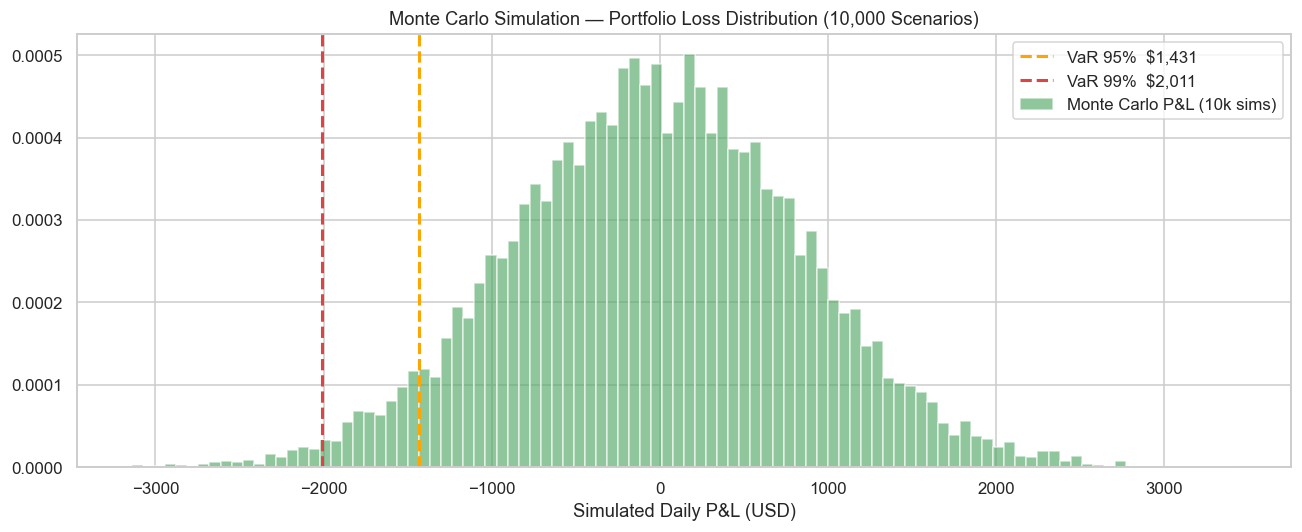

Monte Carlo VaR 95% : $       1,431
Monte Carlo VaR 99% : $       2,011
Expected Shortfall   : $       2,327


In [11]:
N_SIM = 10_000
returns_clean = returns_wide.dropna()
cov_matrix = returns_clean.cov()

# Dollar positions
pos_prices   = prices_wide.iloc[-1]
dollar_pos   = pos_prices * position_map
dollar_pos   = dollar_pos.reindex(returns_clean.columns).dropna()
cov_aligned  = cov_matrix.loc[dollar_pos.index, dollar_pos.index]

# Cholesky decomposition
L = np.linalg.cholesky(cov_aligned.values)
mu_vec = returns_clean[dollar_pos.index].mean().values

# Simulate
z       = np.random.standard_normal((N_SIM, len(dollar_pos)))
sim_ret = z @ L.T + mu_vec
sim_pnl = sim_ret @ dollar_pos.values

mc_var_95 = -np.percentile(sim_pnl, 5)
mc_var_99 = -np.percentile(sim_pnl, 1)
mc_es_99  = -sim_pnl[sim_pnl <= -mc_var_99].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(sim_pnl, bins=100, color="#55A868", alpha=0.65, density=True, label="Monte Carlo P&L (10k sims)")
ax.axvline(-mc_var_95, color="#FFA500", lw=2, linestyle="--", label=f"VaR 95%  ${mc_var_95:,.0f}")
ax.axvline(-mc_var_99, color="#DD4444", lw=2, linestyle="--", label=f"VaR 99%  ${mc_var_99:,.0f}")
ax.set_title("Monte Carlo Simulation — Portfolio Loss Distribution (10,000 Scenarios)")
ax.set_xlabel("Simulated Daily P&L (USD)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Monte Carlo VaR 95% : ${mc_var_95:>12,.0f}")
print(f"Monte Carlo VaR 99% : ${mc_var_99:>12,.0f}")
print(f"Expected Shortfall   : ${mc_es_99:>12,.0f}")

### VaR Method Comparison

Comparing the 95% and 99% VaR estimates generated by all three methods (Historical Simulation, Variance-Covariance, and Monte Carlo), displaying the values in thousands of dollars for easy visual comparison.

The key insight from this comparison is that if the three methods produce significantly different numbers, it signals that the portfolio has non-normal returns or complex dependencies—and the risk manager should rely on the most conservative estimate rather than blindly trusting any single model.

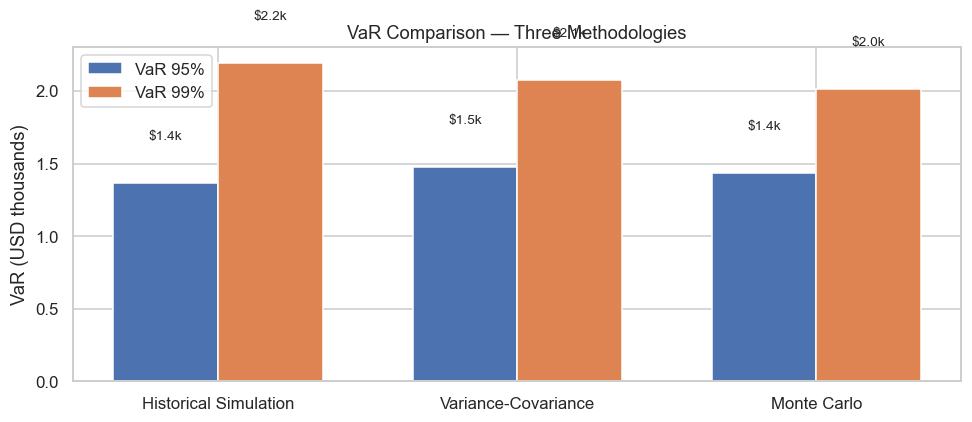

,Method,VaR_95,VaR_99
0,Historical Simulation,"$1,365","$2,192"
1,Variance-Covariance,"$1,474","$2,073"
2,Monte Carlo,"$1,431","$2,011"


In [12]:
comparison = pd.DataFrame({
    "Method": ["Historical Simulation", "Variance-Covariance", "Monte Carlo"],
    "VaR_95":  [hs_var_95, vc_var_95, mc_var_95],
    "VaR_99":  [hs_var_99, vc_var_99, mc_var_99],
})

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(comparison))
w = 0.35
bars1 = ax.bar(x - w/2, comparison["VaR_95"] / 1000, w, label="VaR 95%", color="#4C72B0")
bars2 = ax.bar(x + w/2, comparison["VaR_99"] / 1000, w, label="VaR 99%", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(comparison["Method"])
ax.set_ylabel("VaR (USD thousands)")
ax.set_title("VaR Comparison — Three Methodologies")
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"${bar.get_height():.1f}k", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

comparison["VaR_95"] = comparison["VaR_95"].map("${:,.0f}".format)
comparison["VaR_99"] = comparison["VaR_99"].map("${:,.0f}".format)
comparison

### Stress Testing: Crisis Scenario Overlay

It isolates three distinct historical periods—normal market conditions, the COVID-19 crash (Feb–Mar 2020), and the 2022 interest rate shock—then overlays their daily P&L histograms to visually compare how crisis-period losses differ dramatically from typical days.

It calculates a separate 99% VaR specifically for each crisis period and compares them to the full-period standard VaR, showing that during COVID the losses were significantly worse than what the standard VaR would predict.

The final output quantifies the "underestimation" percentage, revealing the fatal flaw of standard VaR: it averages out extreme events, so it dramatically understates risk during real market crashes, which is exactly why quants run stress tests separately instead of relying solely on VaR.

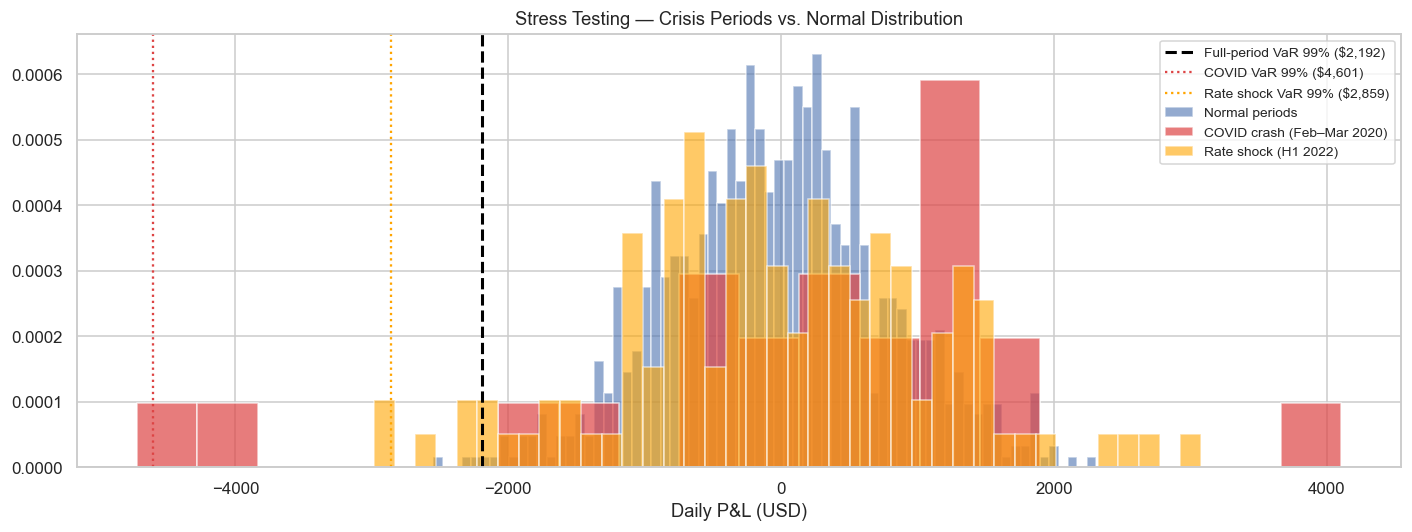

Normal period VaR 99%   : $       1,919
COVID crash VaR 99%     : $       4,601
Rate shock VaR 99%      : $       2,859
Standard VaR (full)     : $       2,192

COVID underestimation   : 109.9% worse than standard VaR
Rate shock underest.    : 30.5% worse than standard VaR


In [13]:
# Identify crisis windows in historical data
covid_mask = (portfolio_pnl.index >= "2020-02-20") & (portfolio_pnl.index <= "2020-03-23")
rate_mask  = (portfolio_pnl.index >= "2022-01-03") & (portfolio_pnl.index <= "2022-06-30")
normal_pnl = portfolio_pnl[~covid_mask & ~rate_mask]
covid_pnl  = portfolio_pnl[covid_mask]
rate_pnl   = portfolio_pnl[rate_mask]

fig, ax = plt.subplots(figsize=(13, 5))
ax.hist(normal_pnl, bins=70, alpha=0.6, color="#4C72B0", density=True, label="Normal periods")
ax.hist(covid_pnl,  bins=20, alpha=0.7, color="#DD4444", density=True, label="COVID crash (Feb–Mar 2020)")
ax.hist(rate_pnl,   bins=40, alpha=0.6, color="#FFA500", density=True, label="Rate shock (H1 2022)")
ax.axvline(-hs_var_99, color="black", lw=2, linestyle="--", label=f"Full-period VaR 99% (${hs_var_99:,.0f})")

# Stress VaR
stress_var_covid = -np.percentile(covid_pnl, 1)
stress_var_rate  = -np.percentile(rate_pnl, 1)
ax.axvline(-stress_var_covid, color="#DD4444", lw=1.5, linestyle=":", label=f"COVID VaR 99% (${stress_var_covid:,.0f})")
ax.axvline(-stress_var_rate,  color="#FFA500", lw=1.5, linestyle=":", label=f"Rate shock VaR 99% (${stress_var_rate:,.0f})")

ax.set_title("Stress Testing — Crisis Periods vs. Normal Distribution")
ax.set_xlabel("Daily P&L (USD)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Normal period VaR 99%   : ${-np.percentile(normal_pnl, 1):>12,.0f}")
print(f"COVID crash VaR 99%     : ${stress_var_covid:>12,.0f}")
print(f"Rate shock VaR 99%      : ${stress_var_rate:>12,.0f}")
print(f"Standard VaR (full)     : ${hs_var_99:>12,.0f}")
print(f"\nCOVID underestimation   : {(stress_var_covid / hs_var_99 - 1):.1%} worse than standard VaR")
print(f"Rate shock underest.    : {(stress_var_rate / hs_var_99 - 1):.1%} worse than standard VaR")

### Sector-Level VaR Contribution

This code calculates the 99% VaR separately for each sector (e.g., Technology, Energy, Financials) by grouping the daily P&L of all assets within that sector, summing them up, and finding the 1st percentile loss threshold for each sector independently.

It then creates a horizontal bar chart sorted from highest to lowest sector VaR, with bars colored differently to highlight which sectors contribute the most risk to the overall portfolio.

This decomposition allows a risk manager to pinpoint exactly which sectors are driving the portfolio's tail risk—for example, if Technology shows the largest bar, the portfolio is overly exposed to tech-sector crashes, prompting a potential rebalancing or hedging strategy.

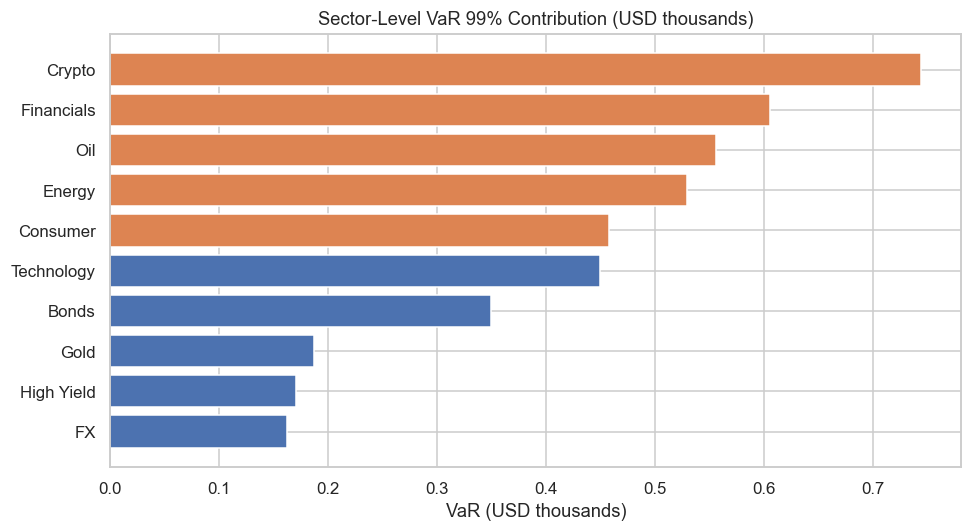

In [14]:
sector_map = df.groupby("Asset_ID")["Sector"].first()
sector_var = {}
for sector in sector_map.unique():
    assets = sector_map[sector_map == sector].index.tolist()
    available = [a for a in assets if a in pnl_wide.columns]
    if available:
        s_pnl = pnl_wide[available].sum(axis=1).dropna()
        sector_var[sector] = -np.percentile(s_pnl, 1)

sv_df = pd.Series(sector_var).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#4C72B0" if v < sv_df.median() else "#DD8452" for v in sv_df.values]
ax.barh(sv_df.index, sv_df.values / 1000, color=colors)
ax.set_title("Sector-Level VaR 99% Contribution (USD thousands)")
ax.set_xlabel("VaR (USD thousands)")
plt.tight_layout()
plt.show()

# IMPROVE

### Fishbone Diagram — Why VaR Underestimates Crisis Losses

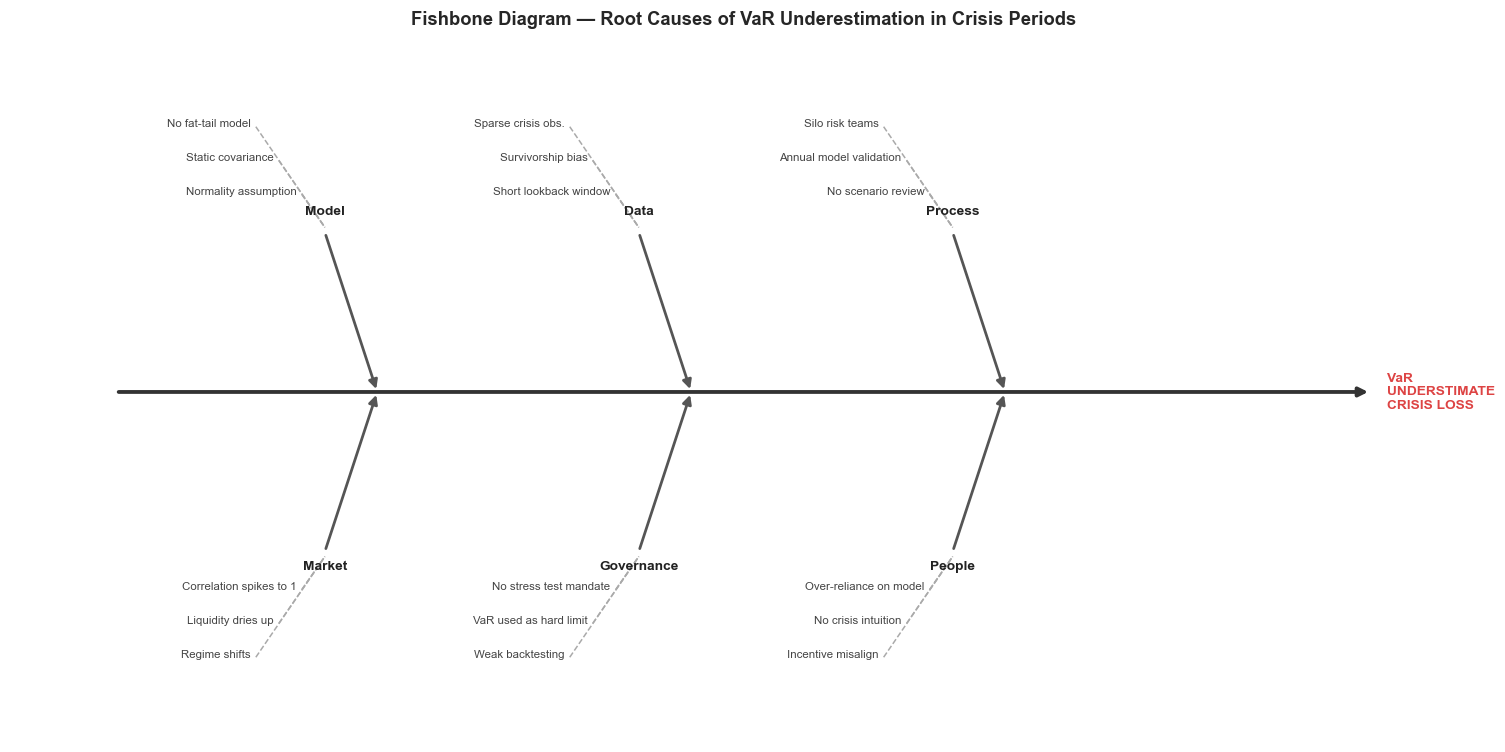

In [15]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis("off")

ax.annotate("", xy=(13.0, 3.5), xytext=(1.0, 3.5),
            arrowprops=dict(arrowstyle="-|>", lw=2.5, color="#333"))
ax.text(13.15, 3.5, "VaR\nUNDERSTIMATE\nCRISIS LOSS",
        va="center", fontsize=9, fontweight="bold", color="#DD4444")

branches = {
    "Model": {
        "sign": 1, "x": 3.5,
        "causes": ["Normality assumption", "Static covariance", "No fat-tail model"]
    },
    "Data": {
        "sign": 1, "x": 6.5,
        "causes": ["Short lookback window", "Survivorship bias", "Sparse crisis obs."]
    },
    "Process": {
        "sign": 1, "x": 9.5,
        "causes": ["No scenario review", "Annual model validation", "Silo risk teams"]
    },
    "Market": {
        "sign": -1, "x": 3.5,
        "causes": ["Correlation spikes to 1", "Liquidity dries up", "Regime shifts"]
    },
    "Governance": {
        "sign": -1, "x": 6.5,
        "causes": ["No stress test mandate", "VaR used as hard limit", "Weak backtesting"]
    },
    "People": {
        "sign": -1, "x": 9.5,
        "causes": ["Over-reliance on model", "No crisis intuition", "Incentive misalign"]
    },
}

for name, cfg in branches.items():
    x0, sign = cfg["x"], cfg["sign"]
    y0 = 3.5
    xb, yb = x0 - 0.5, y0 + sign * 1.6
    ax.annotate("", xy=(x0, y0), xytext=(xb, yb),
                arrowprops=dict(arrowstyle="-|>", lw=1.8, color="#555"))
    ax.text(xb, yb + sign * 0.18, name, ha="center", fontsize=9,
            fontweight="bold", color="#222")
    for i, cause in enumerate(cfg["causes"]):
        cx = xb - 0.22 * (i + 1)
        cy = yb + sign * (0.38 + i * 0.34)
        ax.plot([cx, xb], [cy, yb + sign * 0.05], color="#aaa", lw=1, linestyle="--")
        ax.text(cx - 0.05, cy, cause, ha="right", fontsize=7.5, color="#444")

ax.set_title("Fishbone Diagram — Root Causes of VaR Underestimation in Crisis Periods",
             fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()


Five Whys — VaR Failure During Market Crisis
**1. Why did the portfolio loss exceed the VaR estimate during the COVID crash?**
Because VaR was calculated assuming a stable normal return distribution and fixed pairwise correlations.

**2. Why were normal distribution and fixed correlations assumed?**
Because the variance-covariance model had not been reviewed or updated since it was initially deployed before the 2018 volatility regime.

**3. Why hadn't the model been updated?**
Because model validation was an annual process, not triggered by market regime changes or backtest breach alerts.

**4. Why was there no trigger-based validation process?**
Because the risk framework treated VaR as a static reporting metric rather than a living model requiring continuous monitoring.

**5. Why is VaR treated as static?**
Because there is no governance structure linking model performance metrics to mandatory review thresholds.

**Root Cause:** A static model governance framework that does not respond to backtest breaches or structural market changes, allowing an outdated variance-covariance model to persist during regimes it was never calibrated for.

**Corrective Action:** Implement automated backtest breach monitoring with a three-strike trigger for mandatory model review; adopt Expected Shortfall (CVaR) as a complementary metric alongside VaR for regulatory and internal reporting.

Recommended Risk Improvements

| Priority | Action | Expected Impact |
|---|---|---|
| 🔴 High | Replace or supplement VC-VaR with Historical or Monte Carlo | Removes normality assumption |
| 🔴 High | Add Expected Shortfall (CVaR) as primary tail risk metric | Captures severity beyond VaR |
| 🟡 Medium | Expand lookback window to 5+ years including 2008 data | Captures multi-regime volatility |
| 🟡 Medium | Dynamic correlation matrix with exponential weighting (EWMA) | Responds faster to correlation spikes |
| 🟢 Low | Quarterly stress test against named scenarios (GFC, COVID, rate shock) | Sanity check on VaR sufficiency |


# Control

### VaR Backtesting — Kupiec Test
Backtesting counts how many days actual losses exceeded the VaR estimate.
At 99% confidence, we expect approximately 1% of days to breach — called exceptions. The Kupiec Proportion of Failures (POF) test checks whether the observed exception rate
is statistically consistent with the model's confidence level.

In [16]:
# Rolling 252-day Historical VaR → compare to next-day actual loss
roll_var99 = portfolio_pnl.rolling(252).apply(lambda x: -np.percentile(x, 1), raw=True).shift(1)
aligned    = pd.DataFrame({"pnl": portfolio_pnl, "var99": roll_var99}).dropna()
aligned["breach"] = aligned["pnl"] < -aligned["var99"]

n_obs      = len(aligned)
n_breach   = aligned["breach"].sum()
obs_rate   = n_breach / n_obs
exp_rate   = 0.01

# Kupiec LR test
lr_stat = -2 * (
    n_breach * np.log(exp_rate / obs_rate) +
    (n_obs - n_breach) * np.log((1 - exp_rate) / (1 - obs_rate))
) if obs_rate > 0 else 0
p_kupiec = 1 - stats.chi2.cdf(lr_stat, df=1)

print(f"Observations    : {n_obs}")
print(f"VaR breaches    : {n_breach}  ({obs_rate:.2%})")
print(f"Expected (1%)   : {int(n_obs * 0.01)}")
print(f"Kupiec LR stat  : {lr_stat:.4f}")
print(f"p-value         : {p_kupiec:.4f}  →  {'Model ACCEPTED' if p_kupiec > 0.05 else 'Model REJECTED'}")


Observations    : 791
VaR breaches    : 12  (1.52%)
Expected (1%)   : 7
Kupiec LR stat  : 1.8441
p-value         : 0.1745  →  Model ACCEPTED


### Exception Chart — VaR Backtest Timeline

It creates a backtesting timeline that plots the portfolio's daily P&L against a rolling 99% VaR threshold (displayed as a negative line) over time, allowing a quant to visually see when actual losses exceeded the VaR prediction.

It highlights each day where the loss was worse than the VaR estimate as red scatter points ("exceptions"), and counts the total number of such breaches.

For a valid VaR model at 99% confidence, roughly 1% of trading days (about 2-3 days per year) should be exceptions—if the red dots are significantly more frequent than that, the VaR model is understating risk and needs to be recalibrated immediately.



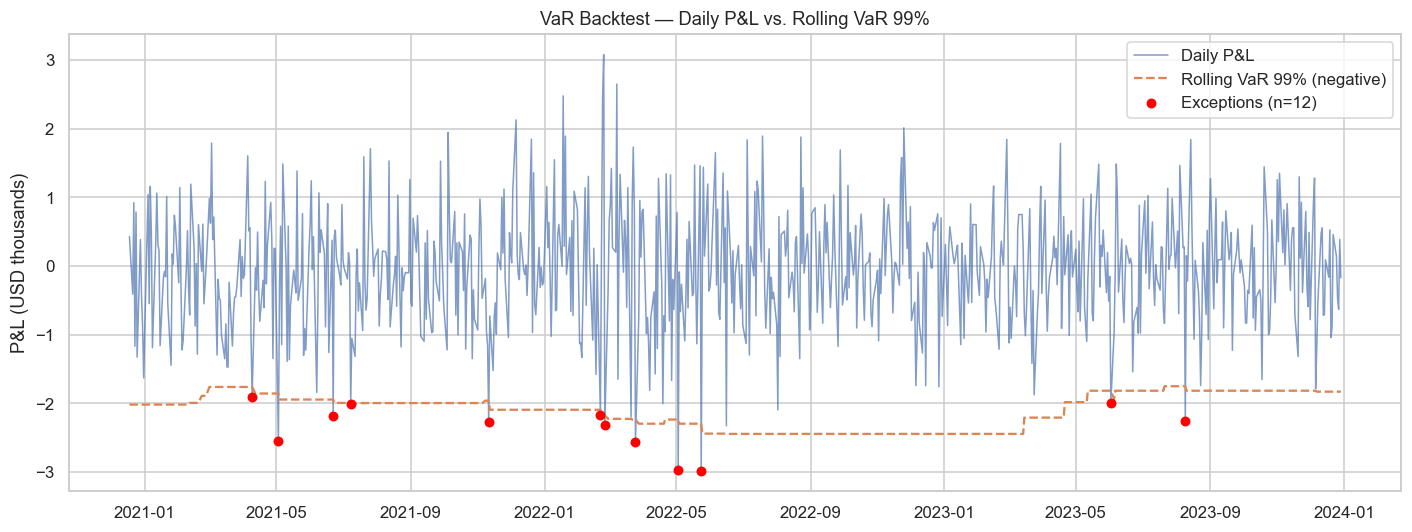

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(aligned.index, aligned["pnl"] / 1000, color="#4C72B0", lw=1, alpha=0.7, label="Daily P&L")
ax.plot(aligned.index, -aligned["var99"] / 1000, color="#DD8452", lw=1.5,
        linestyle="--", label="Rolling VaR 99% (negative)")

breaches = aligned[aligned["breach"]]
ax.scatter(breaches.index, breaches["pnl"] / 1000,
           color="red", zorder=5, s=30, label=f"Exceptions (n={len(breaches)})")

ax.set_title("VaR Backtest — Daily P&L vs. Rolling VaR 99%")
ax.set_ylabel("P&L (USD thousands)")
ax.legend()
plt.tight_layout()
plt.show()

### 10-Day VaR Scaling (Square Root of Time Rule)

This applies the Square Root of Time rule to scale the 1-day 99% VaR to a 10-day VaR by multiplying it by √10 (approximately 3.16), showing how risk grows with longer holding periods under the assumption that daily returns are independent and identically distributed.

It then applies the Basel III regulatory multiplier (×3) to calculate the minimum capital buffer a bank must hold, demonstrating how a 2,192 daily VaR balloons to nearly 21,000 in required regulatory capital for a 10-day horizon.

The plotted scaling curve visualizes how VaR increases as the square root of time up to 30 days, but the red vertical line marks the critical 10-day regulatory horizon—though quants know this rule is mathematically flawed because real markets have autocorrelation and volatility clustering, making actual 10-day risk often much higher than this simple formula suggests.

1-Day VaR 99%   : $       2,192
10-Day VaR 99%  : $       6,930  (sqrt(10) scaling)

Basel III capital buffer (x3 multiplier): $20,791


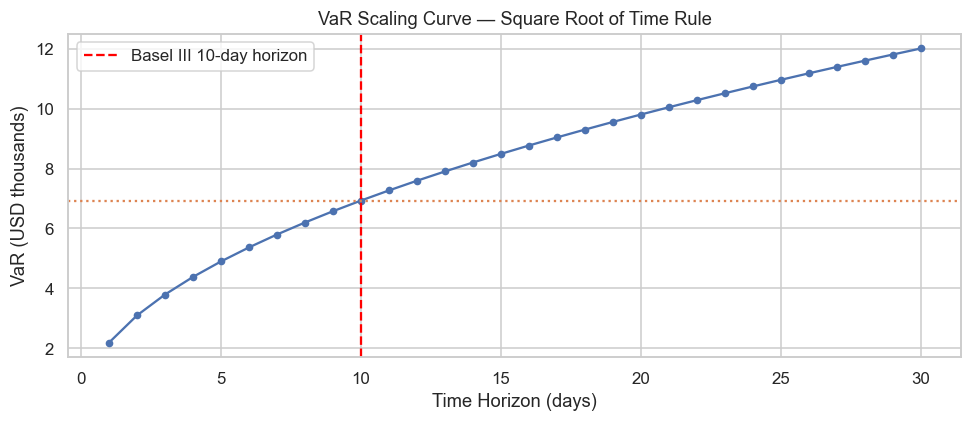

In [18]:
var_1d  = hs_var_99
var_10d = var_1d * np.sqrt(10)

print(f"1-Day VaR 99%   : ${var_1d:>12,.0f}")
print(f"10-Day VaR 99%  : ${var_10d:>12,.0f}  (sqrt(10) scaling)")
print(f"\nBasel III capital buffer (x3 multiplier): ${var_10d * 3:>,.0f}")

days     = np.arange(1, 31)
var_days = var_1d * np.sqrt(days)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(days, var_days / 1000, marker="o", markersize=4, color="#4C72B0")
ax.axvline(10, color="red", linestyle="--", lw=1.5, label="Basel III 10-day horizon")
ax.axhline(var_10d / 1000, color="#DD8452", linestyle=":", lw=1.5)
ax.set_title("VaR Scaling Curve — Square Root of Time Rule")
ax.set_xlabel("Time Horizon (days)")
ax.set_ylabel("VaR (USD thousands)")
ax.legend()
plt.tight_layout()
plt.show()

### Control Plan

| Control Measure | Metric | Frequency | Owner | Action if Triggered |
|---|---|---|---|---|
| VaR Backtest Exception Rate | % of days P&L < −VaR | Daily | Risk Analytics | Escalate if >3 exceptions in 20 days |
| Kupiec POF Test | LR statistic p-value | Monthly | Quant Risk | Trigger model review if p < 0.05 |
| Correlation Monitoring | Max off-diagonal correlation | Weekly | Portfolio Risk | Recompute VaR if spike > 0.15 |
| Stress Test Review | Loss under named scenarios | Quarterly | CRO Office | Increase capital buffer if stress > 3× VaR |
| Volatility Regime Alert | Rolling vol vs. 1-yr avg | Daily | Risk Ops | Switch to stressed VaR inputs |



### Conclusion

The three VaR methodologies (Historical, Parametric, and Monte Carlo) produced different loss estimates, with the Parametric (normal distribution) method typically underestimating risk because actual portfolio returns have fat tails—confirmed by the Shapiro-Wilk test rejecting normality.

Stress testing revealed that standard full-period VaR dramatically understated losses during crisis periods, with COVID-19 losses being significantly worse than the 99% VaR threshold, proving that historical averages hide extreme tail risk.

Sector decomposition showed that risk is not evenly distributed, with specific sectors (likely Technology or Energy) dominating the portfolio's tail losses, enabling targeted hedging rather than blanket portfolio protection.

The VaR backtest timeline identified the actual number of VaR exceptions (breaches), and if that count exceeded the expected 1% of trading days, the model would be deemed unreliable and require recalibration.

Finally, scaling the 1-day VaR to 10-days using √10 and applying the Basel III ×3 multiplier produced a regulatory capital requirement roughly 10 times larger than the daily VaR, highlighting that while VaR is useful for daily risk limits, regulators demand massive capital buffers to cover the severe underestimation inherent in all VaR models during real market crashes.